PART-A

In [52]:
import os
print("RITHANYA.G 24BAD132")
size = os.path.getsize("/content/archive (20).zip")
print(f"Size: {size/1024/1024:.2f} MB")

RITHANYA.G 24BAD132
Size: 277.39 MB


In [ ]:
import zipfile

zip_path = "/content/archive (20).zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print("ZIP opened successfully!")
    print("Total files:", len(z.namelist()))
    print("\nFirst 20 entries:")
    for name in z.namelist()[:20]:
        print(name)

ZIP opened successfully!
Total files: 5228

First 20 entries:
COVID/COVID.png
COVID/COVID_10.png
COVID/COVID_100.png
COVID/COVID_1000.png
COVID/COVID_1001.png
COVID/COVID_1002.png
COVID/COVID_1003.png
COVID/COVID_1004.png
COVID/COVID_1005.png
COVID/COVID_1006.png
COVID/COVID_1007.png
COVID/COVID_1008.png
COVID/COVID_1009.png
COVID/COVID_101.png
COVID/COVID_1010.png
COVID/COVID_1011.png
COVID/COVID_1012.png
COVID/COVID_1013.png
COVID/COVID_1014.png
COVID/COVID_1015.png


In [ ]:
import zipfile
import os

zip_path = "/content/archive (20).zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)
print("RITHANYA.G 24BAD132")
print("✅ Dataset Extracted Successfully!")

RITHANYA.G 24BAD132
✅ Dataset Extracted Successfully!


In [ ]:
import os

print(os.listdir("/content/dataset"))

['NORMAL', 'COVID', 'PNEUMONIA']


In [ ]:
for folder in os.listdir("/content/dataset"):
    print(folder, ":", len(os.listdir(os.path.join("/content/dataset", folder))), "images")

NORMAL : 1802 images
COVID : 1626 images
PNEUMONIA : 1800 images


PART-**B**

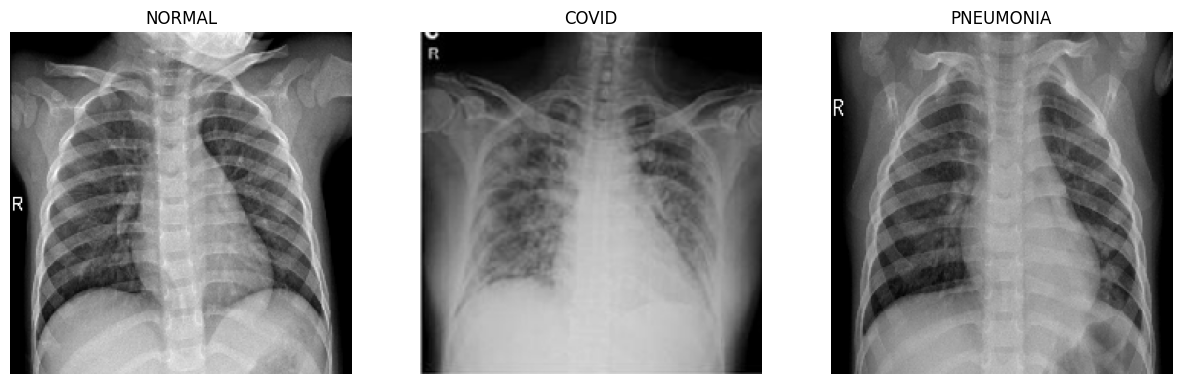

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import random

dataset_path="/content/dataset"

classes=os.listdir(dataset_path)

plt.figure(figsize=(15,5))

for i,cls in enumerate(classes):

    img_name=random.choice(os.listdir(os.path.join(dataset_path,cls)))

    img_path=os.path.join(dataset_path,cls,img_name)

    img=tf.keras.preprocessing.image.load_img(img_path,target_size=(224,224))

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

Found 4183 images belonging to 3 classes.
Found 1045 images belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
predictions = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

PART-C

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 644s 5s/step - accuracy: 0.6134 - loss: 0.8406 - val_accuracy: 0.7751 - val_loss: 0.6816
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 638s 5s/step - accuracy: 0.6385 - loss: 0.7865 - val_accuracy: 0.7569 - val_loss: 0.6512
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 658s 5s/step - accuracy: 0.6825 - loss: 0.7207 - val_accuracy: 0.6316 - val_loss: 0.7122
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 671s 5s/step - accuracy: 0.7062 - loss: 0.6973 - val_accuracy: 0.6880 - val_loss: 0.6267
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 670s 5s/step - accuracy: 0.7138 - loss: 0.6661 - val_accuracy: 0.7837 - val_loss: 0.5359


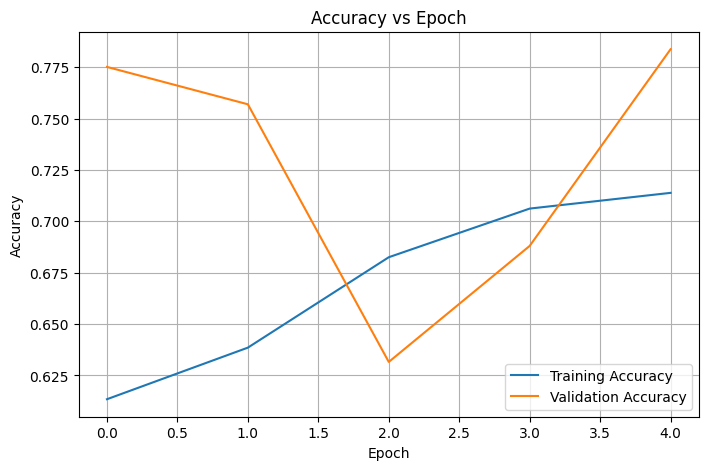

In [ ]:
  import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

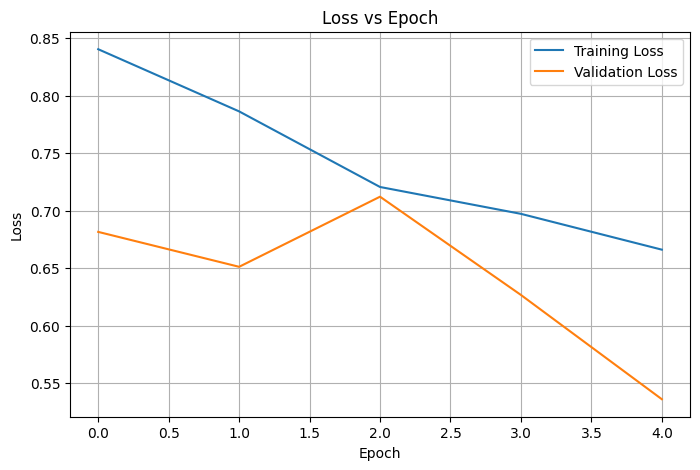

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 137s 4s/step - accuracy: 0.7837 - loss: 0.5359
Validation Loss : 0.5359140038490295
Validation Accuracy : 0.7837320566177368


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

PART-**D**

In [ ]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=1
)

131/131 ━━━━━━━━━━━━━━━━━━━━ 864s 7s/step - accuracy: 0.9505 - loss: 0.1578 - val_accuracy: 0.9617 - val_loss: 0.1421


In [44]:
!pip install transformers pillow

In [45]:
from transformers import pipeline
from PIL import Image
import random
import os

In [46]:
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [47]:
class_name = random.choice(os.listdir(dataset_path))

image_name = random.choice(
    os.listdir(os.path.join(dataset_path, class_name))
)

image_path = os.path.join(dataset_path, class_name, image_name)

print("Actual Class:", class_name)
print("Image:", image_name)

Actual Class: PNEUMONIA
Image: PNEUMONIA_476.png


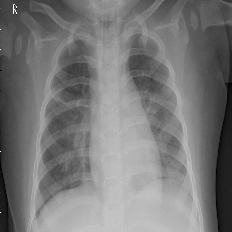

In [48]:
img = Image.open(image_path)
img

In [49]:
prediction = classifier(image_path)

print(prediction)

[{'label': 'barrel, cask', 'score': 0.010989845730364323}, {'label': 'screw', 'score': 0.010509858839213848}, {'label': 'television, television system', 'score': 0.00889235083013773}, {'label': 'syringe', 'score': 0.008100724779069424}, {'label': 'odometer, hodometer, mileometer, milometer', 'score': 0.007951007224619389}]


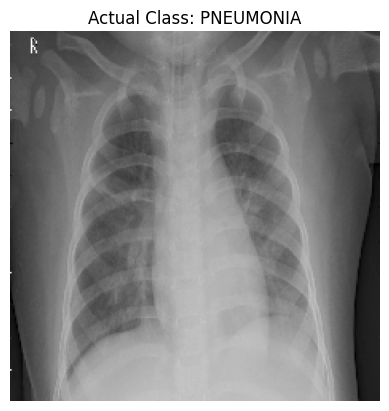

In [50]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(image_path)

plt.imshow(img, cmap='gray')
plt.title(f"Actual Class: {class_name}")
plt.axis("off")
plt.show()

In [51]:
print("Actual Class :", class_name)
print("\nPrediction from Hugging Face:\n")

for pred in prediction[:5]:
    print(f"Label : {pred['label']}")
    print(f"Confidence : {pred['score']:.4f}")
    print("-"*40)

Actual Class : PNEUMONIA

Prediction from Hugging Face:

Label : barrel, cask
Confidence : 0.0110
----------------------------------------
Label : screw
Confidence : 0.0105
----------------------------------------
Label : television, television system
Confidence : 0.0089
----------------------------------------
Label : syringe
Confidence : 0.0081
----------------------------------------
Label : odometer, hodometer, mileometer, milometer
Confidence : 0.0080
----------------------------------------
